In [324]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
#from collections import namedtuple
import math
import ast
from scipy.stats import chisquare
from scipy import special
from scipy.optimize import minimize
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from shapely.geometry import LineString
from scipy.stats import crystalball
import scipy.special as sc


In [356]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 2)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2080<= dataframe3.iloc[i,9][1]< 2120):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_1tonne_single):
    NTD_data = []
    no_NTD_data = []

    NTD_data = []

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][j] in dataframe_1tonne_single.iloc[i,17]:
                NTD_data.append(i) 

    NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][0] and dataframe_1tonne_single.iloc[i,10][1] not in dataframe_1tonne_single.iloc[i,17]:
                no_NTD_data.append(i) 

    no_NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    F_NTD = []
    E_NTD = []
    N_NTD = []
    C_NTD = []
    O_NTD = []
    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] == 'F':
            F_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'E':
            E_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'N':
            N_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'C':
            C_NTD.append(i)
        else:
            O_NTD.append(i)
            
    F_NTD = no_NTD_data[no_NTD_data.index.isin(F_NTD)]
    F_NTD=F_NTD.reset_index(drop=True)
    
    E_NTD = no_NTD_data[no_NTD_data.index.isin(E_NTD)]
    E_NTD=E_NTD.reset_index(drop=True)
    
    N_NTD = no_NTD_data[no_NTD_data.index.isin(N_NTD)]
    N_NTD=N_NTD.reset_index(drop=True)
    
    C_NTD = no_NTD_data[no_NTD_data.index.isin(C_NTD)]
    C_NTD=C_NTD.reset_index(drop=True)
    
    return F_NTD, E_NTD, C_NTD, N_NTD

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][1])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [357]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)

NTD_single, no_NTD_single = NTD_Sort(dataframe_single)
F_NTD, E_NTD, C_NTD, N_NTD= Topology_Sort(NTD_single)
F, E, C, N= Topology_Sort(no_NTD_single)

NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_single)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_2801/3028205152.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_2801/905049170.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_2801/905049170.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

In [382]:
def CrystalBallFunc(x, mu, sigma, alpha, n, A,f):
    E0 = min(x)
    E1=max(x)
    Ec = (E0+E1)/2
    p = (1+A*(x-Ec))/(E1-E0)
    return (1-f)*crystalball.pdf(x, beta=alpha, m=n, loc=mu, scale=sigma)+f*p
    
def NegLogLCrystalBall(params,data):
    mu, sigma, alpha, n, A, f = params
    E0 = min(data)
    E1 = max(data)
    x = CrystalBallFunc(data,mu, sigma, alpha, n, A, f, E0, E1)
    x = x[x>0]
    LogL = np.sum(np.log(x))
    return -2*LogL

def MinimizeNegLogLCrystalBall(data, initial_params):
    E0 = min(data)
    E1 = max(data)
    Ec = (E0+E1)/2
    bound_A = 1/(Ec-E0)
    result = minimize(NegLogLCrystalBall, initial_params, args=(data),
                      method='L-BFGS-B', bounds=[(0, None), (0, None), (0, None), (0, 18), (-bound_A, bound_A), (0,1)])
    return result.x

def Chi2(data, arr):
    mu, sigma, alpha, n, A, f = arr
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num, range = [int(min(data)), int(max(data))])
    
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = CrystalBallFunc(filtered_bin_centers, mu, sigma, alpha, n, A, f, E0, E1)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Graph(data, arr):
    mu_fit, sigma_fit, alpha_fit, n_fit, A_fit, f_fit = arr
    x_values = np.linspace(min(data), max(data), 1000)
    bin_num = int(max(data) - min(data))
    bin_width = (max(data) - min(data))/bin_num
    
    fitted_pdf = CrystalBallFunc(x_values, mu_fit, sigma_fit, alpha_fit, n_fit, A_fit, f_fit, min(data), max(data))*len(data)*bin_width
    linear_bkg = (f_fit*(1+A_fit*(x_values-((min(data)+max(data))/2)))/(max(data)-min(data)))*len(data)*bin_width
    crystal_ball = (1-f_fit)*crystalball.pdf(x_values, beta=alpha, m=n, loc=mu, scale=sigma)*len(data)*bin_width
    
    return x_values, fitted_pdf, crystal_ball, linear_bkg

def Residual_Plot(data, arr):
    mu, sigma, alpha, n, A, f = arr
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = CrystalBallFunc(filtered_bin_centers, mu, sigma, alpha, n, A, f, E0, E1)*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)
    

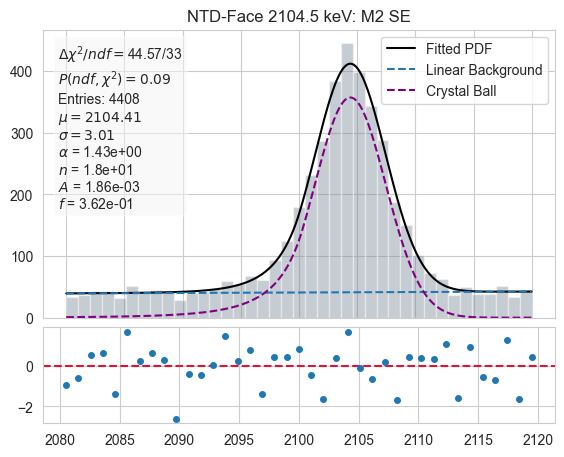

In [371]:
data = np.asarray(NTD_2100)
mu = 2104.4138503844847
sigma = 3.04
alpha = 1.35
n = 5
A = 1.71e-3
f = 0.36

initial_parms = [mu, sigma, alpha, n, A, f]
data_fit= MinimizeNegLogLCrystalBall(data, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
x_values = np.linspace(min(data), max(data), 1000)
bin_num = int(max(data) - min(data))
bin_width = (max(data) - min(data))/bin_num

x_values, fitted_pdf, crystal, linear = Graph(data, data_fit)

chisq = Chi2(data, data_fit)
fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(chisq, decimals=2)) +'/' +str(int(max(data) - min(data)) - 6, ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(int(max(data) - min(data)) - 6,chisq), ),
    'Entries: ' + (str(len(data))),
    r'$\mu=%.2f$' % (data_fit[0], ),
    r'$\sigma=%.2f$' % (data_fit[1], ),
    r'$\alpha$ = ' + str(np.format_float_scientific(data_fit[2], precision = 2), ),
    r'$n$ = ' + str(np.format_float_scientific(data_fit[3], precision = 2), ),
    r'$A$ = ' + str(np.format_float_scientific(data_fit[4], precision = 2), ),
    r'$f$ = ' + str(np.format_float_scientific(data_fit[5], precision = 2),)
    ))

ax.plot(x_values, fitted_pdf,label='Fitted PDF', color='black')
ax.plot(x_values, linear, label='Linear Background', linestyle='--')
ax.plot(x_values, crystal, label='Crystal Ball', linestyle = '--', color='purple')

ax.hist(data, bins = int(max(data) - min(data)) , color='slategray', alpha=0.4)
ax.text(0.03, 0.95, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('NTD-Face 2104.5 keV: M2 SE')
ax.legend()

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(data, data_fit)[0],Residual_Plot(data, data_fit)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')

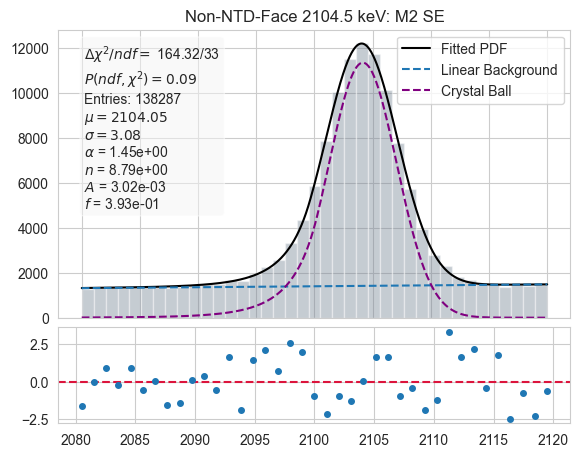

In [372]:
noNTD_2100, noNTD_511 = PrimarySecondarySplit(no_NTD_single)

mu = 2104.158147262019
sigma = 2.897366961722745
alpha = 1.35
n = 8.79
A = 3.59e-3
f = 0.43

initial_parms = [mu, sigma, alpha, n, A, f]
NoNTD_fit= MinimizeNegLogLCrystalBall(noNTD_2100, initial_parms)

x_valuesNoNTD, fitted_pdfNoNTD, crystalNoNTD, linearNoNTD = Graph(noNTD_2100, NoNTD_fit)

chisqNonNTD = Chi2(noNTD_2100, NoNTD_fit)
fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
textNoNTD = '\n'.join((r'$\Delta\chi^2/ndf=$ '+ str(np.round(chisqNonNTD, decimals=2)) +'/' +str(int(max(noNTD_2100) - min(noNTD_2100)) - 6, ),
    r'$P(ndf,\chi^2)=%.2f$' % (PValue(int(max(noNTD_2100) - min(noNTD_2100)) - 6,chisq), ),
    'Entries: ' + (str(len(noNTD_2100))),
    r'$\mu=%.2f$' % (NoNTD_fit[0], ),
    r'$\sigma=%.2f$' % (NoNTD_fit[1], ),
    r'$\alpha$ = ' + str(np.format_float_scientific(NoNTD_fit[2], precision = 2), ),
r'$n$ = ' + str(np.format_float_scientific(NoNTD_fit[3], precision = 2), ),
r'$A$ = ' + str(np.format_float_scientific(NoNTD_fit[4], precision = 2), ),
    r'$f$ = ' + str(np.format_float_scientific(NoNTD_fit[5], precision = 2),)
    ))

ax.plot(x_valuesNoNTD, fitted_pdfNoNTD,label='Fitted PDF', color='black')
ax.plot(x_valuesNoNTD, linearNoNTD, label='Linear Background', linestyle='--')
ax.plot(x_valuesNoNTD, crystalNoNTD, label='Crystal Ball', linestyle = '--', color='purple')

ax.hist(noNTD_2100, bins = int(max(noNTD_2100) - min(noNTD_2100)) , color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textNoNTD, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('Non-NTD-Face 2104.5 keV: M2 SE')
ax.legend()

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(noNTD_2100, NoNTD_fit)[0],Residual_Plot(noNTD_2100, NoNTD_fit)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')

In [373]:
initial_parms = [mu, sigma, alpha, n, A, f]

F_2100, F_511 = PrimarySecondarySplit(F)
C_2100, C_511 = PrimarySecondarySplit(C)
N_2100, N_511 = PrimarySecondarySplit(N)
E_2100, E_511 = PrimarySecondarySplit(E)

Carr = MinimizeNegLogLCrystalBall(C_2100, initial_parms)
Earr = MinimizeNegLogLCrystalBall(E_2100, initial_parms)
Narr = MinimizeNegLogLCrystalBall(N_2100, initial_parms)
Farr = MinimizeNegLogLCrystalBall(F_2100, initial_parms)

In [374]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def TopologyPlots(hist_data, initial_parms, topologies):
    bin_num = []
    xvals = []
    chi2s = []
    fitvals = []
    linearvals = []
    crystalvals = []
    
    for i in range(len(hist_data)):
        x, PDF_fit, crystal, linear = Graph(hist_data[i], initial_parms[i])
        bin_num.append(int(max(hist_data[i])-min(hist_data[i])))
        xvals.append(x)
        fitvals.append(PDF_fit)
        linearvals.append(linear)
        crystalvals.append(crystal)
        
        chi2s.append(Chi2(hist_data[i], initial_parms[i]))
    
    pvals = []
    
    for j in chi2s:
        pvals.append(PValue(bin_num[0],j))
    
    means = []
    sigmas = []
    alphas =[]
    ns = []
    As = []
    fs = []
    
    for i in range(len(initial_parms)):
        means.append(initial_parms[i][0])
        sigmas.append(initial_parms[i][1])
        alphas.append(initial_parms[i][2])
        ns.append(initial_parms[i][3])
        As.append(initial_parms[i][4])
        fs.append(initial_parms[i][5])
        
    data = { 'Topologies': topologies,
        'Bin Num': bin_num,
    'Histogram Data': hist_data,
        'X-axis': xvals,
        'Fit': fitvals,
        'Crystal': crystalvals,
        'Linear': linearvals,
        'Means': means,
        'Sigmas': sigmas,
        'Alphas': alphas,
        'n': ns, 
        'A': As,
        'f': fs, 
        'Chi2': chi2s,
        'p-value': pvals}
    
    df = pd.DataFrame(data)
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    props = dict(boxstyle='round', facecolor='whitesmoke')

    for i, ax in enumerate(axs.flatten()):
        if i < len(df):
            divider = make_axes_locatable(ax)
            
            text = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(df['Chi2'][i], decimals=2)) + '/' + str(df['Bin Num'][i] - 6, ),
            r'$P(ndf,\chi^2)=%.2f$' % (df['p-value'][i], ),
            'Entries: ' + (str(len(df['Histogram Data'][i]))),
            r'$\mu=%.2f$' % (df['Means'][i], ),
            r'$\sigma=%.2f$' % (df['Sigmas'][i], ),
            r'$\alpha=%.2f$' % (df['Alphas'][i], ),
            r'$n$ = ' + str(np.format_float_scientific(df['n'][i], precision = 2), ),
            r'$A$ = ' + str(np.format_float_scientific(df['A'][i], precision = 2), ),
            r'$f$ = ' + str(np.format_float_scientific(df['f'][i], precision = 2), )))
            
            ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
            
            ax.hist(df['Histogram Data'][i], bins=df['Bin Num'][i], color='slategray', alpha=0.4)
            ax.plot(df['X-axis'][i], df['Fit'][i], label='Fitted PDF', color='black')
            ax.plot(df['X-axis'][i], df['Crystal'][i], label='Crystal Ball', linestyle='--', color='purple')
            ax.plot(df['X-axis'][i], df['Linear'][i], label='Linear Background', linestyle='--', color='blue')
            ax.set_title(df["Topologies"][i])
            ax.legend(loc='upper right')
            
            ax2 = divider.append_axes("bottom", size="30%", pad=0.05)
            ax.figure.add_axes(ax2)
            ax2.errorbar(Residual_Plot(hist_data[i], initial_parms[i])[0],Residual_Plot(hist_data[i], initial_parms[i])[1], fmt='o',markersize=4)
            ax2.axhline(0, linestyle='--', color='crimson')
            
            
            
    plt.tight_layout()
    plt.show()

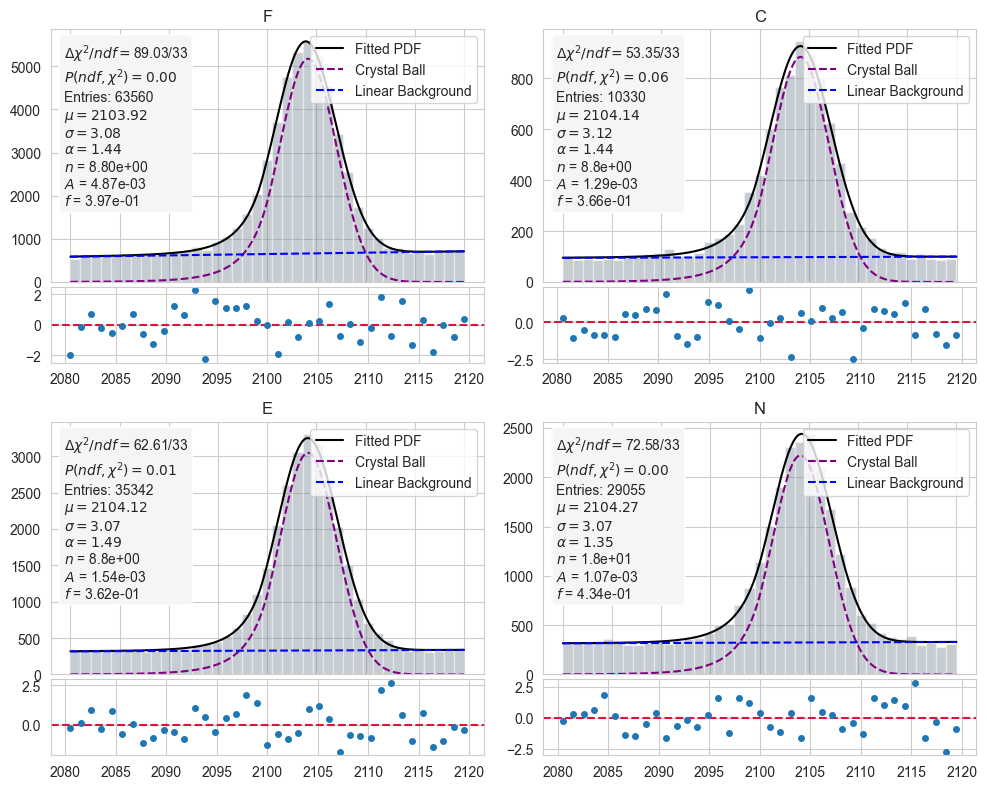

In [375]:
hist_data = [F_2100, C_2100, E_2100, N_2100]
initial_parms = [Farr, Carr, Earr, Narr]
topologies = ['F', 'C', 'E', 'N']

TopologyPlots(hist_data, initial_parms, topologies)

In [351]:
print(Chi2(F_2100, Farr))

98.28048321071894


Text(0.5, 1.0, 'E')

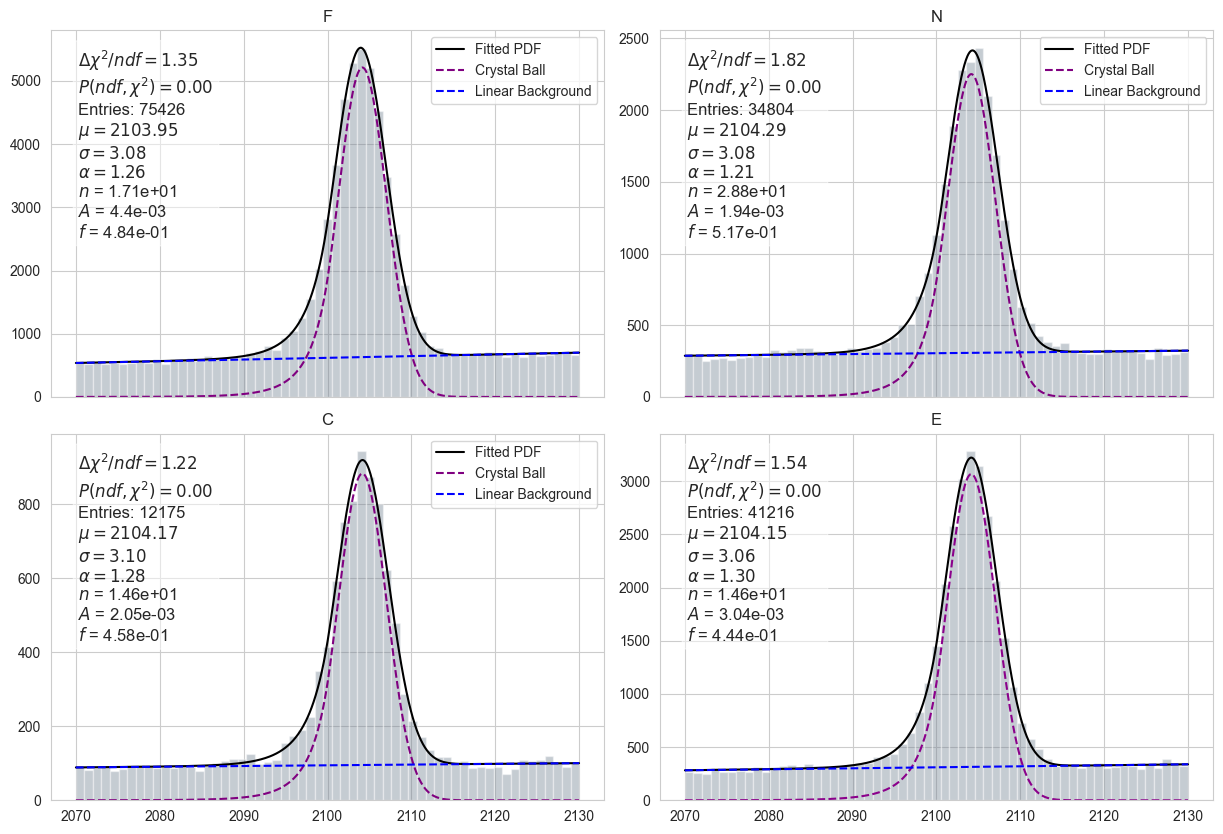

In [40]:
fig, ax = plt.subplots(2,2, sharex='col',  figsize=(15, 10))
# fig.text(0.04, 0.5, 'Energy (keV)', va='center', rotation = 'vertical')
# fig.text(0.5, 0.04, 'Counts', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
# fig.suptitle('Non-NTD Face 2104 keV Topology Fits')
plt.subplots_adjust(wspace=0.1, hspace=0.1)

textF = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Fchi2/(int(max(F_2100) - min(F_2100)) - 6), ),
    r'$P(ndf,\chi^2)=%.2f$' % (1-sc.gammainc(6/2, Fchi2/2), ),
    'Entries: ' + (str(len(F_2100))),
    r'$\mu=%.2f$' % (Fmu_fit, ),
    r'$\sigma=%.2f$' % (Fsigma_fit, ),
    r'$\alpha=%.2f$' % (Falpha_fit, ),
    r'$n$ = ' + str(np.format_float_scientific(Fn_fit, precision = 2), ),
    r'$A$ = ' + str(np.format_float_scientific(FA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Ff_fit, precision = 2), )))

ax[0,0].plot(Fx, F_fit,label='Fitted PDF', color='black')
ax[0,0].plot(Fx, Fcrystal, label = 'Crystal Ball', linestyle='--', color='purple')
ax[0,0].plot(Fx, Flinear, label = 'Linear Background', linestyle='--', color='blue')

ax[0,0].hist(F_2100, bins = int(max(F_2100) - min(F_2100)) , color='slategray', alpha=0.4)
ax[0,0].text(0.05, 0.95, textF, transform=ax[0,0].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('F')
ax[0,0].legend()
###########

textC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Cchi2/(int(max(C_2100) - min(C_2100)) - 6), ),
    r'$P(ndf,\chi^2)=%.2f$' % (1-sc.gammainc(6/2, Cchi2/2), ),
    'Entries: ' + (str(len(C_2100))),
    r'$\mu=%.2f$' % (Cmu_fit, ),
    r'$\sigma=%.2f$' % (Csigma_fit, ),
    r'$\alpha=%.2f$' % (Calpha_fit, ),
    r'$n$ = ' + str(np.format_float_scientific(Cn_fit, precision = 2), ),
    r'$A$ = ' + str(np.format_float_scientific(CA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Cf_fit, precision = 2), )))

ax[1,0].plot(Cx, C_fit,label='Fitted PDF', color='black')
ax[1,0].plot(Cx, Ccrystal, label = 'Crystal Ball', linestyle='--', color='purple')
ax[1,0].plot(Cx, Clinear, label = 'Linear Background', linestyle='--', color='blue')


ax[1,0].hist(C_2100, bins = int(max(C_2100) - min(C_2100)), color='slategray', alpha=0.4)
ax[1,0].text(0.05, 0.95, textC, transform=ax[1,0].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('C')
ax[1,0].legend()
#########

textN = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Nchi2/(int(max(N_2100) - min(N_2100))-6), ),
    r'$P(ndf,\chi^2)=%.2f$' % (1-sc.gammainc(6/2, Nchi2/2), ),
    'Entries: ' + (str(len(N_2100))),
    r'$\mu=%.2f$' % (Nmu_fit, ),
    r'$\sigma=%.2f$' % (Nsigma_fit, ),
    r'$\alpha=%.2f$' % (Nalpha_fit, ),
    r'$n$ = ' + str(np.format_float_scientific(Nn_fit, precision = 2), ),
    r'$A$ = ' + str(np.format_float_scientific(NA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Nf_fit, precision = 2), )))

ax[0,1].plot(Nx, N_fit,label='Fitted PDF', color='black')
ax[0,1].plot(Nx, Ncrystal, label = 'Crystal Ball', linestyle='--', color='purple')
ax[0,1].plot(Nx, Nlinear, label = 'Linear Background', linestyle='--', color='blue')

ax[0,1].hist(N_2100, bins = int(max(N_2100) - min(N_2100)), color='slategrey', alpha=0.4)
ax[0,1].text(0.05, 0.95, textN, transform=ax[0,1].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('N')
ax[0,1].legend()
########

textE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Echi2/(int(max(E_2100) - min(E_2100))-6), ),
    r'$P(ndf,\chi^2)=%.2f$' % (1-sc.gammainc(6/2, Echi2/2), ),
    'Entries: ' + (str(len(E_2100))),
    r'$\mu=%.2f$' % (Emu_fit, ),
    r'$\sigma=%.2f$' % (Esigma_fit, ),
    r'$\alpha=%.2f$' % (Ealpha_fit, ),
    r'$n$ = ' + str(np.format_float_scientific(En_fit, precision = 2), ),
    r'$A$ = ' + str(np.format_float_scientific(EA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Ef_fit, precision = 2), )))

ax[1,1].plot(Ex, E_fit,label='Fitted PDF', color='black')
ax[1,1].plot(Ex, Ecrystal, label = 'Crystal Ball', linestyle='--', color='darkmagenta')
ax[1,1].plot(Ex, Elinear, label = 'Linear Background', linestyle='--', color='blue')

ax[1,1].hist(E_2100, bins = int(max(E_2100) - min(E_2100)), color='slategrey', alpha=0.4)
ax[1,1].text(0.05, 0.95, textE, transform=ax[1,1].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('E')

In [224]:
def NegLogLikelihoodGuassLinear(params,data):
    mu, sigma, alpha, n, A,f = params
    E0 = min(data)
    E1 = max(data)
    LogL = 0
    for k in data:
        x = CrystalBallFunc(k,mu, sigma,alpha, n, A,f, E0, E1)
        LogL += np.log(x)
    return -2*LogL

def Uncertainity(data, mu, sigma, alpha,n, A,f):
    params = [mu, sigma, alpha,n, A,f]
    arr1 = NegLogLikelihoodGuassLinear(params, data)
    arr2 = arr1 - min(arr1)
    xaxis = LineString(np.column_stack((arr2,np.linspace(1,1, len(arr2)))))
    if isinstance(mu, float) == False: 
        curve = LineString(np.column_stack((mu, arr2)))
        intersection = xaxis.intersection(curve)
        if str(intersection) == 'LINESTRING Z EMPTY':
            intersection_indices = np.where(np.isclose(arr2, np.linspace(1,1, len(arr2)), atol=0.05))[0]
            intersection = mu[intersection_indices]
    elif isinstance(mu, float) == True:
        curve = LineString(np.column_stack((sigma, arr2)))
        intersection = curve.intersection(xaxis)
        if str(intersection) == 'LINESTRING Z EMPTY':
            intersection_indices = np.where(np.isclose(arr2, np.linspace(1,1, len(arr2)), atol=0.5))[0]
            intersection = sigma[intersection_indices]
        # intersection_y = arr2[intersection_indices]
        # intersection = list(zip(intersection_x, intersection_y))
    return intersection, arr2

def Errors(mu_intersections, means):
    upper_errs = []
    lower_errs = []

    for i in range(len(mu_intersections)):
        if mu_intersections[i][0] < mu_intersections[i][1]:
            upper_errs.append(mu_intersections[i][1])
            lower_errs.append(mu_intersections[i][0])
        else:
            upper_errs.append(mu_intersections[i][0])
            lower_errs.append(mu_intersections[i][1])

    top_errs = []
    bot_errs = []
    for i in range(len(upper_errs)):
        top_errs.append(abs(means[i]-upper_errs[i]))
        bot_errs.append(abs(means[i]-lower_errs[i]))

    asymmetric_errormu = np.array(list(zip(bot_errs, top_errs))).T
    return asymmetric_errormu

In [225]:
Fmu_fit, Fsigma_fit, Falpha_fit, Fn_fit, FA_fit,Ff_fit = Farr
Cmu_fit,Csigma_fit, Calpha_fit, Cn_fit,CA_fit, Cf_fit = Carr
Nmu_fit, Nsigma_fit, Nalpha_fit, Nn_fit,NA_fit, Nf_fit = Narr
Emu_fit, Esigma_fit, Ealpha_fit, En_fit,EA_fit, Ef_fit = Earr

Fmu_arr = np.linspace(Fmu_fit-5, Fmu_fit+5, 1000)
Cmu_arr = np.linspace(Cmu_fit-5, Cmu_fit+5, 1000)
Nmu_arr = np.linspace(Nmu_fit-5, Nmu_fit+5, 1000)
Emu_arr = np.linspace(Emu_fit-5, Emu_fit+5, 1000)

Fintersection_mu, Ferror_mu = Uncertainity(F_2100, Fmu_arr, Fsigma_fit, Falpha_fit, Fn_fit, FA_fit,Ff_fit)
Cintersection_mu, Cerror_mu = Uncertainity(C_2100, Cmu_arr,Csigma_fit, Calpha_fit, Cn_fit,CA_fit, Cf_fit)
Nintersection_mu, Nerror_mu = Uncertainity(N_2100, Nmu_arr, Nsigma_fit, Nalpha_fit, Nn_fit,NA_fit, Nf_fit)
Eintersection_mu, Eerror_mu = Uncertainity(E_2100, Emu_arr, Esigma_fit, Ealpha_fit, En_fit,EA_fit, Ef_fit)

In [22]:
mu_arr = np.linspace(mu_fit-1, mu_fit+5, 1000)
intersection_mu, error_mu = Uncertainity(data, mu_arr, sigma_fit, alpha_fit, n_fit, A_fit,f_fit)
noNTDmu_arr = np.linspace(mu_fitNoNTD-2, mu_fitNoNTD+2, 1000)
noNTDintersection_mu, noNTDerror_mu = Uncertainity(noNTD_2100, noNTDmu_arr, sigma_fitNoNTD, alpha_fitNoNTD, n_fitNoNTD, A_fitNoNTD, f_fitNoNTD)

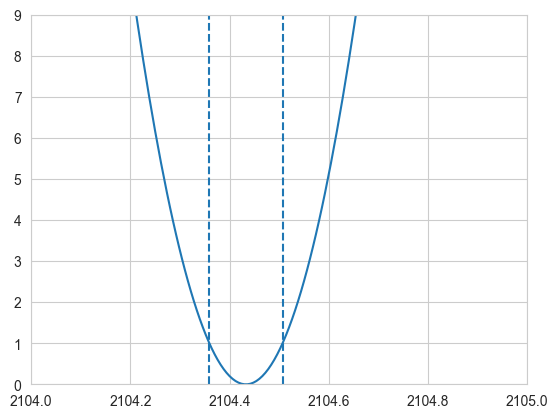

In [27]:
plt.plot(mu_arr, error_mu)
plt.ylim(0,9)
plt.xlim(2104,2105)
plt.axvline(intersection_mu.geoms[0].x, linestyle='--')
plt.axvline(intersection_mu.geoms[1].x, linestyle='--')

In [197]:
Fsigma_arr = np.linspace(Fsigma_fit/2, Fsigma_fit*2, 1000)
Csigma_arr = np.linspace(Csigma_fit/2, Csigma_fit*2, 1000)
Esigma_arr = np.linspace(Esigma_fit/1.5, Esigma_fit*1.5, 1000)
Nsigma_arr = np.linspace(Nsigma_fit/1.5, Nsigma_fit*1.5, 1000)

Fintersection_sigma, Ferror_sigma = Uncertainity(F_2100, Fmu_fit, Fsigma_arr, Falpha_fit, Fn_fit,FA_fit, Ff_fit)
Cintersection_sigma, Cerror_sigma = Uncertainity(C_2100, Cmu_fit, Csigma_arr, Calpha_fit, Cn_fit,CA_fit, Cf_fit)
Nintersection_sigma, Nerror_sigma = Uncertainity(N_2100, Nmu_fit, Nsigma_arr, Nalpha_fit, Nn_fit,NA_fit, Nf_fit)
Eintersection_sigma, Eerror_sigma = Uncertainity(E_2100, Emu_fit, Esigma_arr, Ealpha_fit, En_fit,EA_fit, Ef_fit)

In [198]:
sigma_arr = np.linspace(sigma_fit/1.5, sigma_fit*1.5, 100)
intersection_sigma, error_sigma = Uncertainity(data, mu_fit, sigma_arr, alpha_fit, n_fit,A_fit, f_fit)
noNTDsigma_arr = np.linspace(sigma_fitNoNTD/1.2, sigma_fitNoNTD*1.2, 100)
noNTDintersection_sigma, noNTDerror_sigma = Uncertainity(noNTD_2100, mu_fitNoNTD, noNTDsigma_arr,alpha_fitNoNTD, n_fitNoNTD, A_fitNoNTD, f_fitNoNTD)

Text(0.5, 1.0, 'M2 Single Escape: 2104.5 keV Means')

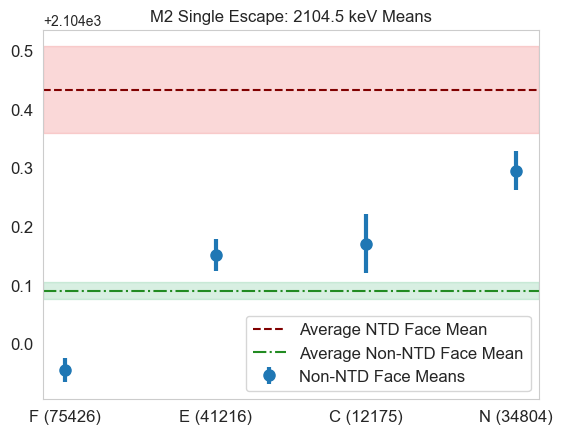

In [199]:
ax = plt.subplot()

topologies = ['F' + ' (' + (str(len(F_2100))) + ')', 'E' + ' ('+ (str(len(E_2100))) + ')', "C" + ' ('+ (str(len(C_2100))) +')', 'N'+ ' ('+ (str(len(N_2100))) + ')']
means = [Fmu_fit, Emu_fit, Cmu_fit, Nmu_fit]
mu_intersections = [[Fintersection_mu.geoms[0].x, Fintersection_mu.geoms[1].x],[Eintersection_mu.geoms[0].x, Eintersection_mu.geoms[1].x],
                   [Cintersection_mu.geoms[0].x, Cintersection_mu.geoms[1].x], [Nintersection_mu.geoms[0].x,Nintersection_mu.geoms[1].x] ]

asymmetric_errormu = Errors(mu_intersections, means)

ax.errorbar(topologies, means, yerr=asymmetric_errormu, fmt='o', ms = 8, elinewidth=3, label='Non-NTD Face Means')
ax.axhspan(intersection_mu.geoms[0].x, intersection_mu.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(mu_fit, color='maroon', linestyle='--', label='Average NTD Face Mean')
ax.axhspan(noNTDintersection_mu.geoms[0].x, noNTDintersection_mu.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(mu_fitNoNTD, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean')

ax.grid(False)
ax.legend(fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.title('M2 Single Escape: 2104.5 keV Means')

Text(0.5, 1.0, 'M2 Single: 2104.5 keV Standard Dev')

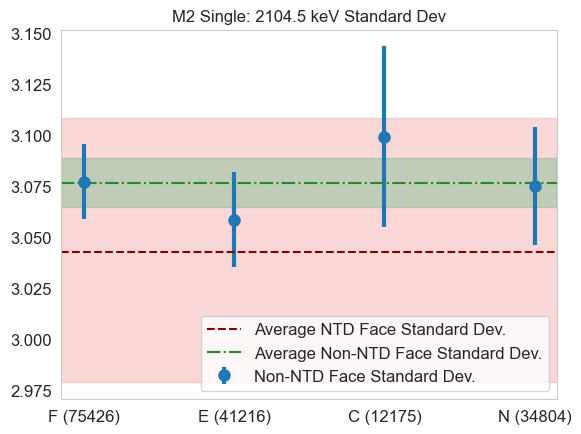

In [201]:
ax = plt.subplot()

topologies = ['F' + ' (' + (str(len(F_2100))) + ')', 'E' + ' ('+ (str(len(E_2100))) + ')', "C" + ' ('+ (str(len(C_2100))) +')', 'N'+ ' ('+ (str(len(N_2100))) + ')']
sds = [Fsigma_fit, Esigma_fit, Csigma_fit, Nsigma_fit]

sds_intersections = [[Fintersection_sigma.geoms[0].x, Fintersection_sigma.geoms[1].x],[Eintersection_sigma.geoms[0].x, Eintersection_sigma.geoms[1].x],
                   [Cintersection_sigma.geoms[0].x, Cintersection_sigma.geoms[1].x], [Nintersection_sigma.geoms[0].x,Nintersection_sigma.geoms[1].x] ]

asymmetric_error = Errors(sds_intersections, sds)

ax.errorbar(topologies, sds, yerr=asymmetric_error, fmt='o', ms=8, elinewidth=3, label='Non-NTD Face Standard Dev.')
ax.axhspan(intersection_sigma.geoms[0].x, intersection_sigma.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(sigma_fit, color='maroon', linestyle='--', label='Average NTD Face Standard Dev.')

ax.axhspan(noNTDintersection_sigma.geoms[0].x, noNTDintersection_sigma.geoms[1].x, color='mediumseagreen', alpha=0.3)
ax.axhline(sigma_fitNoNTD, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Standard Dev.')

ax.legend(loc='lower right',fontsize=12)
ax.grid(False)
plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.title('M2 Single: 2104.5 keV Standard Dev')